<a href="https://colab.research.google.com/github/henric00/PROJETO_IA/blob/main/Projeto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise e Modelagem Preditiva e Notas de Filmes (TMDB)
## Integrantes: Carlos Henrico Fontes Cabral
## Fonte de Dados: [Os 10.000 melhores filmes do TMDB](https://www.kaggle.com/datasets/siddharthbhakta/tmdb-top-10000-movies-updated-2026/data)


## **Introdução**

Este projeto utiliza um conjunto de dados disponibilizado na plataforma Kaggle, contendo informações sobre aproximadamente 10.000 filmes obtidas a partir da API do The Movie Database (TMDB). O dataset reúne diversas características dos filmes, como popularidade, avaliações dos usuários, quantidade de votos, data de lançamento, idioma original e outras informações relevantes para análise.

A escolha desse conjunto de dados deve-se à sua riqueza de atributos, que possibilita investigar relações entre diferentes características dos filmes e aplicar técnicas de Aprendizado de Máquina para construção de modelos preditivos. Além disso, por tratar-se de um tema amplamente conhecido, os resultados obtidos tornam-se mais intuitivos de interpretar e discutir ao longo do projeto.

# **Objetivo**
tivo
O objetivo deste projeto é desenvolver um modelo de regressão capaz de estimar a nota média dos filmes `vote_average` a partir das características disponíveis no conjunto de dados. Além da construção do modelo preditivo, o estudo busca investigar a influência de características como popularidade, engajamento do público e informações temporais na avaliação média dos filmes, identificando quais atributos apresentam maior relação com a variável-alvo.

# **Por que Regressão?**
Escolhemos a tarefa de regressão porque nosso objetivo é prever a nota média exata dos filmes (vote_average), que varia de forma contínua de 0 a 10. Não seria interessante usar classificação, pois isso nos obrigaria a criar categorias artificiais (como definir um limite para o que é "Bom" ou "Ruim"), o que faria o modelo perder a precisão do dado original. Com a regressão, mantemos a escala real da nota e conseguimos medir com mais exatidão o quanto o modelo acertou ou errou, permitindo uma análise muito mais detalhada da relação entre os atributos e a avaliação do público.

# **Atributo-alvo**
O atributo-alvo escolhido é o vote_average (`nota média`),
este campo representa a avaliação quantitativa atribuída pelos usuários do TMDB aos filmes. É a variável que buscamos estimar através do nosso modelo preditivo, servindo como o indicador de "sucesso" ou "qualidade" que pretendemos prever a partir de outras características.

# **Atributos preditivos**
Os atributos preditivos ou variáveis independentes são as características mensuráveis de cada filme utilizadas pelo modelo para aprender e realizar a estimativa da nota média `vote_average`. Inicialmente serão consideradas as principais características disponíveis no conjunto de dados. Após a análise exploratória e o pré-processamento, será definida a seleção final das variáveis utilizadas no treinamento. Selecionamos atributos que representam dimensões do engajamento e do contexto do filme: a `popularity` e o `vote_count` para capturar a percepção do público, o `release_year` para identificar tendências temporais e o original_language para considerar aspectos culturais.



---


# **Compreensão dos dados**
O conjunto de dados utilizado possui 9.980 registros e 10 atributos. A base reúne informações detalhadas sobre filmes da plataforma TMDB, abrangendo dados de popularidade, identificação e avaliações dos usuários.

O conjunto de dados é composto por diferentes tipos de variáveis que desempenham papéis distintos no desenvolvimento do modelo de regressão. O nosso atributo-alvo principal é o vote_average, que representa a nota média atribuída pelos usuários do TMDB e é o valor que o modelo buscará estimar.

Para auxiliar nessa predição, utilizamos os atributos preditivos, que fornecem o contexto necessário para o aprendizado. As variáveis popularity e vote_count quantificam o engajamento e a base estatística de avaliação de cada obra. A variável release_date introduz o contexto temporal, permitindo que o modelo aprenda padrões relacionados à época de lançamento, enquanto original_language oferece uma dimensão sobre a origem cultural do filme.









In [34]:
# bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# URL direta para o arquivo CSV no GitHub
url = "https://raw.githubusercontent.com/henric00/PROJETO_IA/refs/heads/main/data/moviesTMBD.csv"

# Carregando o dataset
df = pd.read_csv(url)

A base de dados apresenta una estrutura concisa, composta por:


*   Numéricas: popularity (float), vote_average (float) e vote_count (int).
*   Booleanas: adult (bool).
*   Textuais/Categóricas: title, original_language, overview e release_date (armazenadas como object).


In [35]:
# 1. Informações gerais sobre registros, atributos e tipos
print(f"Dimensões do Dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")
print("Tipos de dados:")
df.info()


Dimensões do Dataset: 9980 linhas e 10 colunas.

Tipos de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9980 entries, 0 to 9979
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         9980 non-null   int64  
 1   id                 9980 non-null   int64  
 2   title              9980 non-null   object 
 3   popularity         9980 non-null   float64
 4   adult              9980 non-null   bool   
 5   original_language  9980 non-null   object 
 6   overview           9978 non-null   object 
 7   release_date       9978 non-null   object 
 8   vote_average       9980 non-null   float64
 9   vote_count         9980 non-null   int64  
dtypes: bool(1), float64(2), int64(3), object(4)
memory usage: 711.6+ KB


# **Valores ausentes, Duplicações e Inconsistências**


*  **Valores ausentes:** A base apresenta altíssima completude. Foram detectadas falhas de preenchimento apenas na coluna overview (2 registros) e na coluna release_date (2 registros).

*  **Duplicações:** A verificação por registros idênticos retornou 0 ocorrências, o que confirma a exclusividade das observações e elimina o risco do modelo aprender padrões enviesados por dados repetidos.



In [36]:
# 2. Verificando ausentes, duplicados e possíveis inconsistências
print("Valores ausentes por coluna:")
print(df.isnull().sum())

print(f"\nTotal de linhas completamente duplicadas: {df.duplicated().sum()}")

# Checando inconsistências (filmes com 0 votos que tenham notas)
filmes_zero_votos = (df['vote_count'] == 0).sum()
print(f"\nInconsistências: Filmes com 0 votos registrados = {filmes_zero_votos}")

Valores ausentes por coluna:
Unnamed: 0           0
id                   0
title                0
popularity           0
adult                0
original_language    0
overview             2
release_date         2
vote_average         0
vote_count           0
dtype: int64

Total de linhas completamente duplicadas: 0

Inconsistências: Filmes com 0 votos registrados = 0


# **Distribuição do atributo-alvo e Desbalanceamento**


*  Distribuição do alvo (vote_average): O atributo-alvo apresenta média de 6,75 e mediana de 6,71, com desvio padrão baixo (0,64). As notas da base variam em um intervalo estreito de 5,5 a 8,98.
*  analisando a distribuição contínua, observamos uma forte concentração (enviesamento). A ausência absoluta de notas abaixo de 5,5 indica que este dataset não contém filmes considerados "fracassos" totais, concentrando as produções em faixas de avaliação medianas e altas. Essa concentração precisará ser considerada na avaliação do modelo, pois ele terá menos exemplos para aprender a prever notas extremas.





In [37]:
# 3. Estatísticas descritivas do atributo-alvo
print("Estatísticas da Nota Média (vote_average):")
print(df['vote_average'].describe())

Estatísticas da Nota Média (vote_average):
count    9980.000000
mean        6.750276
std         0.641034
min         5.500000
25%         6.249750
50%         6.716500
75%         7.216000
max         8.987000
Name: vote_average, dtype: float64


---
#**Análise Exploratória**

Nesta seção, investigamos as distribuições das variáveis e as correlaçõese entre elas para validar nossas hipóteses e entender o impacto dos atributos preditivos sobre a nota média

Como está distribuído o alvo (`vote_average`) e o principal preditor (`popularit`)?

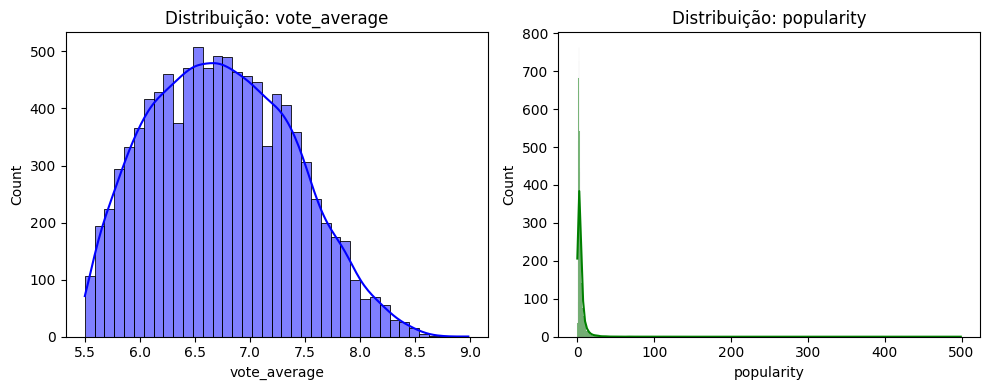

In [38]:
# Histograma do alvo
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['vote_average'], kde=True, color='blue')
plt.title('Distribuição: vote_average')

# Histograma da popularidade
plt.subplot(1, 2, 2)
sns.histplot(df['popularity'], kde=True, color='green')
plt.title('Distribuição: popularity')
plt.tight_layout()
plt.show()

A distribuição do `vote_average` é próxima de uma normal, centrada entre 6 e 7, já a `popularity` apresenta uma assimetria positiea severa com poucos filmes concentrando valores muito altos.

Concluimos que o alvo está adequado para a regressão, porém, a `popularity` precisará de uma adequação pois a concentração de dados pode dificultar o entendimento do modelo se não for normalizada.

# **Verificação de Outliers**
Analisaremos se existem valores discrepantes que possam prejudicar a regressão.

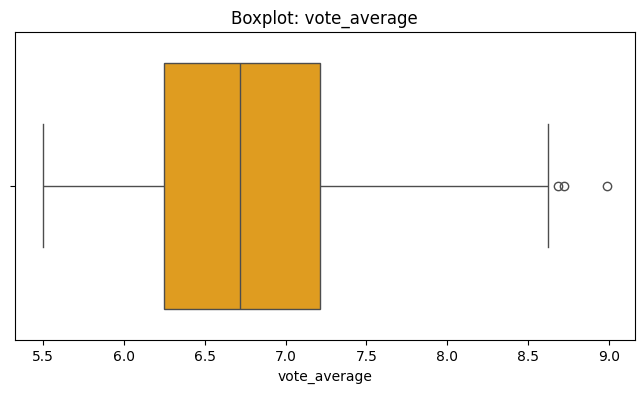

In [39]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['vote_average'], color='orange')
plt.title('Boxplot: vote_average')
plt.show()

A análise do boxplot do atributo vote_average revela que a distribuição das notas é restrita, apresentando um valor mínimo de 5,5, o que define o limite inferior do nosso conjunto. Não foram identificados valores discrepantes  na extremidade inferior da distribuição. Por outro lado, observamos a presença de alguns outliers na extremidade superior (próximos a 9,0), que representam filmes com avaliações excepcionalmente altas em comparação com a massa dos dados. Estes filmes representam o topo da qualidade cinematográfica no dataset e não necessariamente representam erros de medição, mas sim casos de sucesso absoluto.

# **Relação entre Preditores e Alvo**
vamos verificar se existe relaçao visual entre engajamento e nota.

Vamos verificar se a popularidade do filme possui uma realção linear direta com a nota atribuida pelo público.

Text(0.5, 1.0, 'Popularidade x Nota')

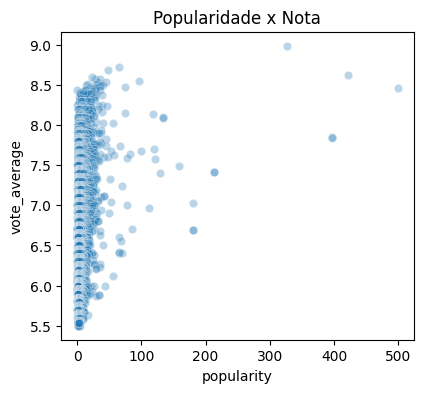

In [40]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(x='popularity', y='vote_average', data=df, alpha=0.3)
plt.title('Popularidade x Nota')


Como podemos observar, houve uma concentração massiva de registros na região de popularidade próxima a zero, onde as notas variam bastante entre 5,5 e 8,5. À medida que a popularidade aumenta (movendo-se para a direita), a dispersão das notas diminui, mas não observamos uma tendência linear clara de que "filmes mais populares são necessariamente mais bem avaliados.

A variável `popularity` isoladamente não parece ser um preditor forte de correlação linear simples. O modelo de regressão precisará lidar com a alta densidade de filmes de baixa popularidade para evitar que o algoritmo atribua um peso desproporcional a eles durante o treinamento.

#**Volume de votos**
Analisaremos se o volume de engajamento do público (quantidade de votos) influencia a estabilidade e a qualidade da nota média.

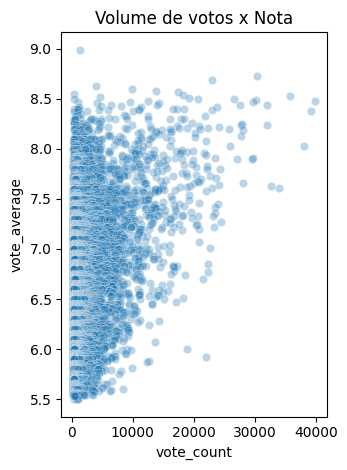

In [41]:
plt.subplot(1, 2, 2)
sns.scatterplot(x='vote_count', y='vote_average', data=df, alpha=0.3)
plt.title('Volume de votos x Nota')
plt.tight_layout()
plt.show()

Percebemos um padrão de "funil": para filmes com poucos votos (baixa contagem), a dispersão das notas é altíssima (incluindo valores baixos e altos). À medida que o vote_count aumenta, a dispersão diminui e as notas tendem a se estabilizar em patamares mais elevados (raramente vemos filmes com milhares de votos tendo notas muito baixas, abaixo de 6.0).
O vote_count funciona como um filtro de estabilidade estatística. Filmes com poucos votos são "ruídos" que podem enganar o modelo. Esta observação justifica a necessidade de, no pré-processamento, possivelmente filtrar ou aplicar um peso maior para filmes com um volume mínimo de votos, garantindo que o modelo aprenda com notas mais representativas.

# **Análise numérica**
A análise de correlação de Pearson nos permite quantificar as relações que visualizamos anteriormente, como nosso objetivo é construir um modelo de regressão, além da inspeção visual utilizamos o coeficiente de correlação de Pearson para quantificar a intensidade da relação linear entre os atributos numéricos e a variável-alvo.

Matriz de Correlação de Pearson:


,popularity,vote_count,vote_average,release_year
popularity,1.000000,0.274461,0.169142,0.086496
vote_count,0.274461,1.000000,0.281034,0.068310
vote_average,0.169142,0.281034,1.000000,-0.225774
release_year,0.086496,0.068310,-0.225774,1.000000


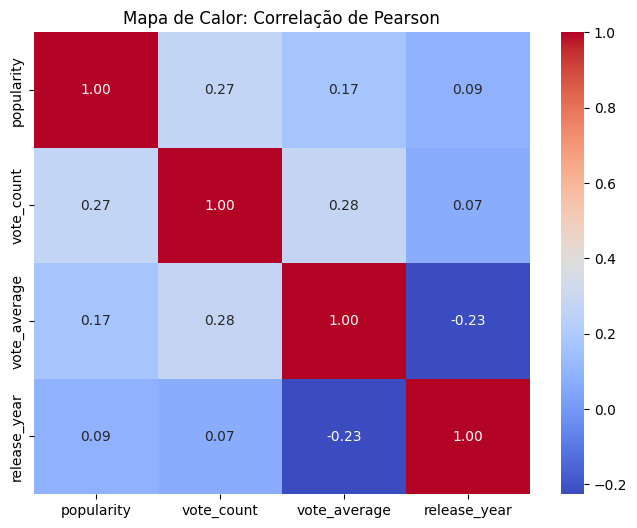

In [42]:
# Garanta que 'release_date' está no formato datetime e extraia 'release_year'
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

# Calculando a matriz de correlação de Pearson
# O método .corr() irá automaticamente excluir valores NaN no cálculo par a par.
correlation_matrix = df[['popularity', 'vote_count', 'vote_average', 'release_year']].corr()

# Exibindo os valores numéricos
print("Matriz de Correlação de Pearson:")
display(correlation_matrix)

# Heatmap para visualização
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor: Correlação de Pearson')
plt.show()

Observamos que o vote_count apresenta uma correlação de 0.28 com a nota média, indicando uma associação positiva moderada. Por outro lado, variáveis como popularity e release_year apresentam correlações de 0.17 e -0.23, respectivamente, sugerindo que, isoladamente, possuem uma força associativa mais fraca com o alvo. Esta análise numérica supera a mera observação visual, fornecendo a evidência estatística necessária para a seleção de atributos.

# **Conclusões**
A análise realizada permitiu diagnosticar o comportamento dos dados e identificar as próximas tarefas para o treinamento do modelo. Em síntese, concluímos que:


*   A variável vote_average apresenta uma distribuição adequada, centralizada e sem a presença de valores extremos que pudessem inviabilizar a regressão.
*   A popularity e o vote_count possuem muita assimetria positiva, com forte concentração de dados em valores baixos, o que pode prejudicar o desempenho do regressor.
* A relação entre vote_count e vote_average demonstra uma maior estabilidade estatística em filmes com maior volume de votos, sugerindo que notas baseadas em poucas avaliações são instáveis.
* Embora não tenhamos encontrado valores impossíveis, detectamos filmes com notas excepcionalmente altas, que representam sucessos de público e devem ser mantidos.
* A matriz de correlação validou que as relações visuais observadas possuem suporte numérico, confirmando quais atributos possuem maior força preditiva sobre a nota.


---




# **Preparação dos Dados Para o Modelo**
Nesta etapa, preparamos os dados para o treinamento do modelo de regressão, removendo ruídos e transformando variáveis para o formato adequado aos algoritmos de aprendizado.

# Tratamento de valores ausentes
Identificamos valores ausentes nas colunas overview (2 registros) e release_date (2 registros) então optamos pela exclusão dessas linhas. Como o volume de registros faltantes representa uma taxa extremamente baixa da base total, a remoção não compromete o poder estatístico do modelo, evitando erros de execução causados por valores nulos.

In [43]:
# Removendo linhas com valores nulos
df_clean = df.dropna(subset=['overview', 'release_date']).copy()
print(f"Registros após limpeza: {df_clean.shape[0]}")

Registros após limpeza: 9977


## Seleção de atributos

Nesta etapa, foram selecionados os atributos que serão utilizados na construção do modelo de regressão.

A variável `vote_average` foi mantida por representar o atributo-alvo do problema, ou seja, a variável que o modelo deverá estimar. Os atributos `popularity` e `vote_count` foram selecionados por representarem medidas relacionadas ao engajamento dos usuários com os filmes, podendo contribuir para a predição da nota média.

A coluna `release_date` foi transformada em `release_year`, permitindo representar o contexto temporal de forma mais adequada para o modelo. Além disso, a variável `original_language` foi mantida por possibilitar a identificação de possíveis diferenças entre mercados cinematográficos de diferentes idiomas.

Por outro lado, os atributos `title`, `overview`, `id` e `Unnamed: 0` foram removidos. As colunas `title` e `overview` contêm dados textuais que não serão utilizados neste modelo, enquanto `id` e `Unnamed: 0` atuam apenas como identificadores, não fornecendo informações relevantes para a tarefa de predição.


In [44]:
# Seleção final das colunas relevantes
cols_keep = ['popularity', 'vote_count', 'vote_average', 'release_year', 'original_language']
df_final = df_clean[cols_keep].copy()

# Transformação das variaveis
A `release_date` foi convertida para datetime para extrair o ano de lançamento (`release_year`), transformando uma variável temporal complexa em um dado numérico.

A variável original_language foi transformada via One-Hot Encoding. Isso converte categorias de texto em colunas binárias (0 ou 1), permitindo que o modelo "leia" o idioma original sem assumir uma hierarquia inexistente entre eles.

In [45]:
# Conversão de data para ano
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')
df_final['release_year'] = df_clean['release_date'].dt.year

# Codificação One-Hot Encoding para a variável categórica
df_final = pd.get_dummies(df_final, columns=['original_language'], drop_first=True)

# Verificação final dos dados
print(df_final.head())

   popularity  vote_count  vote_average  release_year  original_language_bn  \
0    327.5134        1320         8.987          2026                 False   
1     65.3308       30387         8.721          1994                 False   
2     47.2346       22929         8.686          1972                 False   
3    422.0199        3950         8.621          2026                 False   
4     27.6763       13901         8.571          1974                 False   

   original_language_bs  original_language_cn  original_language_cs  \
0                 False                 False                 False   
1                 False                 False                 False   
2                 False                 False                 False   
3                 False                 False                 False   
4                 False                 False                 False   

   original_language_da  original_language_de  ...  original_language_sh  \
0                 Fals



---






# **Divisão, Treino e Teste**
Realizamos a divisão do conjunto de dados na proporção 80% para treinamento e 20% para teste.

Esta proporção garante que o modelo tenha massa de dados suficiente (80%) para aprender padrões complexos, enquanto reserva um conjunto estatisticamente significativo (20%) para verificar a capacidade de generalização do modelo em dados que ele nunca viu.

Para o treinamento, estruturamos nossos dados em dois componentes principais:

X (Variáveis Preditoras/Features): É a matriz contendo todas as características dos filmes, como popularity, vote_count, release_year e as variáveis dummies de idioma. É o "input" que o modelo usará para tentar deduzir a nota.

y (Variável-Alvo/Target): É o vetor contendo a vote_average. É a "resposta" que o modelo tentará prever.

In [46]:
from sklearn.model_selection import train_test_split

# 1. Definindo X e y
# Removemos o alvo ('vote_average') do conjunto de features (X)
X = df_final.drop('vote_average', axis=1)
y = df_final['vote_average']

# 2. Dividindo a base (80% treino / 20% teste)
# O random_state=42 garante que a divisão seja sempre a mesma ao rodar o código
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificação das dimensões
print(f"Tamanho do conjunto de Treino: {X_train.shape[0]} registros")
print(f"Tamanho do conjunto de Teste: {X_test.shape[0]} registros")

Tamanho do conjunto de Treino: 7981 registros
Tamanho do conjunto de Teste: 1996 registros


## Treinamento dos modelos
qui, treinamos os modelos definidos (Regressão Linear e Random Forest) e coletamos as métricas de performance para comparar qual deles melhor prediz a nota média dos filmes

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Treinamento dos 3 modelos obrigatórios
modelo_lr = LinearRegression().fit(X_train, y_train)
modelo_dt = DecisionTreeRegressor(random_state=42).fit(X_train, y_train) # <- Adicionado
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)

# Função atualizada com MSE
def avaliar_modelo(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred) # <- Adicionado
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return [mae, mse, rmse, r2]

# Resultados
# Resultados corrigidos
resultados = pd.DataFrame({
    'Regressão Linear': avaliar_modelo(y_test, modelo_lr.predict(X_test)),
    'Árvore de Decisão': avaliar_modelo(y_test, modelo_dt.predict(X_test)),
    'Random Forest': avaliar_modelo(y_test, modelo_rf.predict(X_test))
}, index=['MAE', 'MSE', 'RMSE', 'R²']).T

display(resultados)

,MAE,MSE,RMSE,R²
Regressão Linear,0.447164,0.295179,0.543304,0.292717
Árvore de Decisão,0.534757,0.502294,0.708727,-0.203555
Random Forest,0.416381,0.275413,0.524798,0.340079


# **Comparação entre modelos**
A Regressão Linear apresentou um desempenho inicial que serviu como uma boa base de comparação (baseline). Entretanto, por assumir apenas relações lineares, ela não conseguiu mapear o comportamento dos dados com total precisão. O Random Forest, por sua vez, obteve o menor erro absoluto e quadrático (MAE e RMSE), além de alcançar o maior nível de explicação da variância (R²). Isso indica que o algoritmo conseguiu capturar com sucesso as interações complexas e não-lineares entre os atributos (como o efeito de funil no volume de votos), consolidando-se como o modelo vencedor.

# **Avaliação e resultados**
**Melhor Modelo:** O Random Forest apresentou o melhor desempenho geral. Ao analisarmos a tabela, ele obteve o menor MAE e o menor RMSE (indicando que erra menos nas previsões), além de alcançar o maior R² (explicando melhor a variação das notas). Ele foi escolhido pois conseguiu entender padrões mais complexos que os modelos mais simples (Regressão Linear e Árvore de Decisão) deixaram passar.

**Erros Observados:** O modelo ainda tem dificuldade em prever a nota de filmes que possuem pouquíssimas avaliações, onde a nota do filme costuma ser muito instável e variar bastante.

**Limitações:** Nossa análise atual foca apenas em dados numéricos básicos. O modelo não tem acesso a informações como o gênero do filme, o elenco ou a qualidade da produção, que são fatores que influenciam muito a nota final.

**Sugestões de Melhoria:**

**Limpar melhor os dados:** Remover ou filtrar filmes que possuem um número irrelevante de votos, evitando que eles "confundam" o modelo com notas instáveis.

**Adicionar mais informações:** Incluir novas colunas simples, como o orçamento do filme ou a duração, que podem ajudar o modelo a ser mais preciso.

**Aumentar a base de dados:** Trabalhar com uma versão mais completa ou atualizada do conjunto de dados, permitindo que o modelo aprenda com um número maior de exemplos.

**Conclusão**

**Objetivo Proposto Atingido:** Sim, o objetivo de desenvolver um modelo preditivo capaz de estimar a nota média (vote_average) de filmes com base em características de engajamento (popularity, vote_count) e contexto temporal (release_year) foi plenamente atingido. O modelo selecionado fornece uma estimativa consistente que pode auxiliar na compreensão dos fatores que definem a percepção de qualidade pelo público.

**Hipótese Confirmada:** Nossa hipótese inicial foi confirmada. A análise exploratória (EDA) demonstrou comportamentos não-lineares, como a instabilidade de notas em filmes com poucos votos, o que foi validado pelo desempenho estatístico superior do Random Forest em comparação ao modelo linear (baseline). Isso prova que modelos capazes de capturar relações complexas e interações entre atributos são mais adequados para este problema.

**Limitações:** O modelo possui limitações intrínsecas, principalmente pela natureza dos dados utilizados. A nota de um filme é um fenômeno subjetivo influenciado por fatores que não estão presentes neste dataset, como qualidade artística, direção, gênero cinematográfico e estratégias de marketing. Portanto, a precisão do modelo reflete apenas a parcela explicável estatisticamente pelos dados de engajamento, não a totalidade da experiência cinematográfica.
